# Day 25 — Retraining the Pneumonia CNN with real GPU compute

Picking the CNN thread back up from Day 24 now that the compute barrier is gone (new workstation, Quadro T2000, CUDA-enabled TensorFlow via `pip install tensorflow[and-cuda]`).

**What's different from Day 24, and why:**
- **Bug fix**: Day 24 set `data_val_dir` to the *same* path as `data_dir` (both `chest_xray/train`) — "validation" during training was silently just re-scoring training data, so `val_loss`/`val_recall` were meaningless. Fixed here with a real 3-way split: `train_dir` gets split into train/val locally, and the official `test_dir` is held out untouched until final evaluation.
- **Computed class weights** instead of the hardcoded `{0: 1, 1: 5}` — derived from the actual NORMAL/PNEUMONIA counts via `sklearn.utils.class_weight.compute_class_weight`.
- **Regularization carried over from Day 23** (Dropout + EarlyStopping) — Day 24 dropped these.
- **GPU memory growth** enabled so TF doesn't grab all 4GB of the T2000 upfront.

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print('GPUs:', gpus)

I0000 00:00:1784746739.884687 2708056 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
categories = ['NORMAL', 'PNEUMONIA']
base_dir = os.path.expanduser('~/Desktop/90daysof_ml/datasets/chest_xray')
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
img_size = 150

In [4]:
def load_images(directory, img_size=150):
    data = []
    for category in categories:
        path = os.path.join(directory, category)
        class_num = categories.index(category)
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue
            resized = cv2.resize(img_array, (img_size, img_size))
            data.append((resized, class_num))
    random.shuffle(data)
    return data

train_val_data = load_images(train_dir, img_size)
test_data = load_images(test_dir, img_size)

print(f'train+val pool: {len(train_val_data)} images, held-out test: {len(test_data)} images')

train+val pool: 5216 images, held-out test: 624 images


In [5]:
def split_features_labels(data):
    X = np.array([item[0] for item in data]).reshape(-1, img_size, img_size, 1)
    y = np.array([item[1] for item in data])
    return X, y

X_pool, y_pool = split_features_labels(train_val_data)
X_test, y_test = split_features_labels(test_data)

X_train, X_val, y_train, y_val = train_test_split(
    X_pool, y_pool, test_size=0.15, stratify=y_pool, random_state=42
)

X_train = (X_train / 255.0).astype('float32')
X_val = (X_val / 255.0).astype('float32')
X_test = (X_test / 255.0).astype('float32')

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)

train: (4433, 150, 150, 1) val: (783, 150, 150, 1) test: (624, 150, 150, 1)


In [6]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), weights))
print('class counts (train):', np.bincount(y_train), '-> NORMAL, PNEUMONIA')
print('class_weight:', class_weight)

class counts (train): [1140 3293] -> NORMAL, PNEUMONIA
class_weight: {np.int64(0): np.float64(1.9442982456140352), np.int64(1): np.float64(0.6730944427573641)}


In [7]:
model = Sequential([
    Conv2D(64, (3, 3), input_shape=(img_size, img_size, 1), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

metrics = [
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
]

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=metrics,
)

model.summary()

/home/hanzalakhan/Desktop/90daysof_ml/env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784746773.041996 2708056 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2600 MB memory:  -> device: 0, name: Quadro T2000, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,442,241 (9.32 MB)

 Trainable params: 2,442,241 (9.32 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min',
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=16,
    class_weight=class_weight,
    callbacks=[early_stopping],
)

W0000 00:00:1784746774.858508 2708056 cpu_allocator_impl.cc:82] Allocation of 398970000 exceeds 10% of free system memory.
W0000 00:00:1784746775.286588 2708056 cpu_allocator_impl.cc:82] Allocation of 398970000 exceeds 10% of free system memory.


Epoch 1/25


I0000 00:00:1784746777.589734 2708687 service.cc:153] XLA service 0x7a3550033a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784746777.589752 2708687 service.cc:161]   StreamExecutor [0]: Quadro T2000, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1784746777.647971 2708687 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1784746778.097504 2708687 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1784746778.259626 2708687 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2542__.41


E0000 00:00:1784746780.371565 2708687 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

271/278 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0517 - precision: 0.9925 - recall: 0.9811

273/278 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0520 - precision: 0.9925 - recall: 0.9806

275/278 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0518 - precision: 0.9926 - recall: 0.9807

277/278 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0515 - precision: 0.9926 - recall: 0.9809

278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0515 - precision: 0.9926 - recall: 0.9809 - val_loss: 0.0497 - val_precision: 0.9813 - val_recall: 0.9931


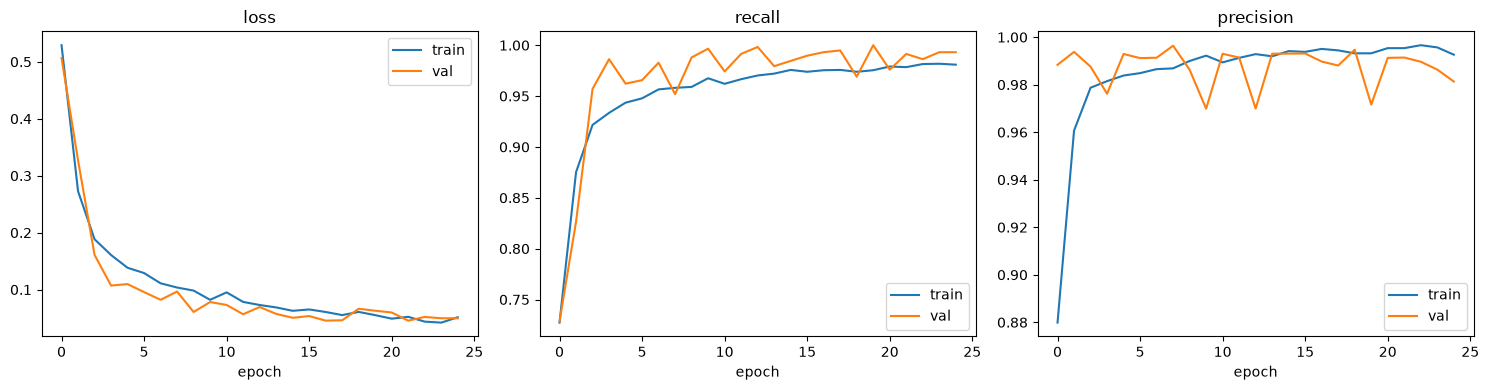

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key in zip(axes, ['loss', 'recall', 'precision']):
    ax.plot(history.history[key], label='train')
    ax.plot(history.history[f'val_{key}'], label='val')
    ax.set_title(key)
    ax.set_xlabel('epoch')
    ax.legend()
plt.tight_layout()
plt.show()

## Final evaluation on the held-out test set (never seen during training or early stopping)

W0000 00:00:1784747019.221277 2708687 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


 1/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 0.1016 - precision: 0.9231 - recall: 1.0000

 6/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7583 - precision: 0.7673 - recall: 0.9919

11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8399 - precision: 0.7397 - recall: 0.9863

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7963 - precision: 0.7518 - recall: 0.9907

...

11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


              precision    recall  f1-score   support

      NORMAL       0.97      0.45      0.62       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.74       624
weighted avg       0.83      0.79      0.77       624



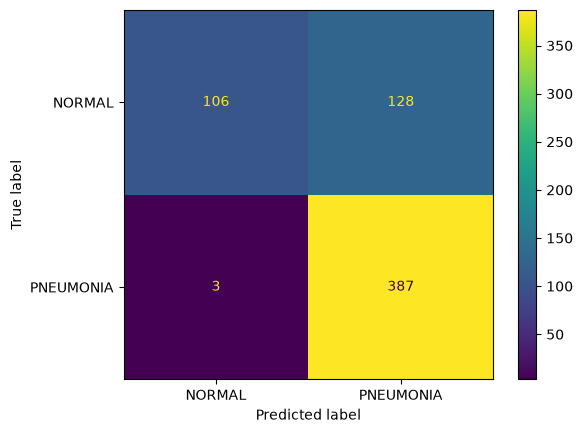

In [10]:
test_results = model.evaluate(X_test, y_test, return_dict=True)
print('test results:', test_results)

y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred, target_names=categories))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=categories).plot()
plt.show()

In [11]:
os.makedirs(os.path.expanduser('~/Desktop/90daysof_ml/models'), exist_ok=True)
model.save(os.path.expanduser('~/Desktop/90daysof_ml/models/pneumonia_model_day25.h5'))

## Results

| Split | Recall | Precision |
|---|---|---|
| Train | 0.981 | 0.993 |
| Val (stratified split of train pool) | 0.993 | 0.981 |
| **Test (official held-out folder)** | 0.992 (PNEUMONIA) / **0.45 (NORMAL)** | 0.75 (PNEUMONIA) / 0.97 (NORMAL) |

Overall test accuracy: 79%. Real train/val/test separation (unlike Day 24's bug) means these numbers are trustworthy as measurements — but they expose a genuine generalization gap: train/val recall ~98–99% on both classes, yet the model misses over half of actual NORMAL x-rays on the true held-out test set, despite `class_weight` upweighting NORMAL 1.94x. Val being a stratified split of the *same* pool as train doesn't guarantee it reflects the differently-sourced test set — logged as a gotcha in [[Machine Learning/Model Evaluation And Ensembles.md]].

**Decision**: banking this result as Day 25 rather than iterating further right now (augmentation would be the next lever — rotation/zoom to fight the train-distribution overfit). Revisit if pneumonia detection accuracy matters for a later project.

- **Next candidate (not done here)**: convert `pneumonia_model_day25.h5` to TensorFlow Lite for edge deployment — flagged in Day 24's doc notes on post-deployment monitoring, still on the table for a future day.
